

## 과제 목적
이번 과제는 수업에서 다룬 **Grain, Cardinality, JOIN, CTE, Window Function, 파생변수**를 실제 Olist 데이터에 직접 적용하는 것을 목표로 합니다. 단순히 SQL이 실행되는지 확인하는 것이 아니라, **결과가 분석적으로 올바른지 직접 검증하고 그 의미를 해석**해야 합니다. 생성형 AI를 사용할 수 있지만, AI가 제안한 쿼리나 해석을 그대로 제출하는 것이 아니라 **본인의 로컬 DB에서 실행 결과를 확인하고, 지표 정의와 JOIN 구조가 타당한지 판단**해야 합니다. 최종적으로 Colab에서 수행한 실험·그래프·해석을 기술블로그에 재구성합니다.

---
> 블로그에는 코드를 그대로 복사하기보다 **왜 이 쿼리를 썼는지 → 어떻게 검증했는지 → 결과를 어떻게 해석했는지**를 중심으로 작성하세요.



# 0. 환경 설정

일반 Colab Hosted Runtime의 `127.0.0.1`은 본인 PC가 아닙니다.  
로컬 MySQL에 접속하려면 **Colab Local Runtime**을 사용하세요.

로컬 터미널/PowerShell에서 Jupyter를 실행한 뒤 Colab의  
**연결 → 로컬 런타임에 연결** 메뉴에 URL을 입력합니다.

```bash
jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True
```


In [6]:
%pip install -q pymysql sqlalchemy pandas


Note: you may need to restart the kernel to use updated packages.


In [4]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd
import matplotlib.pyplot as plt

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist_sql_session"

DB_USER = input("MySQL 사용자명: ").strip()
DB_PASSWORD = getpass("MySQL 비밀번호: ")

url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"},
)

engine = create_engine(url, pool_pre_ping=True)

def run_sql(sql: str) -> pd.DataFrame:
    """SELECT / WITH 쿼리를 실행하고 DataFrame으로 반환합니다."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("DB 연결 객체 생성 완료")


MySQL 사용자명: root
MySQL 비밀번호: ··········
DB 연결 객체 생성 완료


In [5]:
with engine.connect() as conn:
    info = conn.execute(
        text("SELECT VERSION() AS mysql_version, DATABASE() AS current_db;")
    ).mappings().one()

print(dict(info))
print("✅ 연결 성공")


{'mysql_version': '26.7.0', 'current_db': 'olist_sql_session'}
✅ 연결 성공


In [6]:
run_sql("SHOW TABLES;")


,Tables_in_olist_sql_session
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,product_category_name_translation


# 1. 필수 과제

## 빈칸 작성 방식
- `__BLANK_n__` 부분만 올바른 SQL/Python 코드로 바꾸면 됩니다.
- 빈칸을 채워 실행한 뒤  **결과 검증 + 해석**까지 작성하세요.


## 1.1 Grain과 Cardinality 확인

세 테이블의 **한 행이 무엇을 의미하는지** 확인합니다.

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_order_payments_dataset`

### 목표
- 전체 행 수
- 고유 주문 수
- 한 주문이 여러 행으로 나타나는지 확인


In [7]:
# [1.1-A] orders
# 힌트: 고유 주문 수는 order_id에 DISTINCT를 적용합니다.

orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""

orders_grain_df = run_sql(orders_grain_sql)
orders_grain_df


,total_rows,distinct_orders
0,99441,99441


In [8]:
# [1.1-B] order_items
# 힌트: 한 주문 안에 여러 상품 행이 있을 수 있습니다.
# 전체 행 수와 고유 order_id 수의 차이를 확인하세요.

items_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_items_dataset;
"""

items_grain_df = run_sql(items_grain_sql)
items_grain_df


,total_rows,distinct_orders
0,112650,98666


In [9]:
# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df


,total_rows,distinct_orders
0,103886,99440


### 1.1 해석
- `orders`의 한 행: 주문 1건을 의미하며, 전체 행 수와 고유 주문 수가 모두 99,441개이므로, 주문별로 한 행씩 존재한다.
- `order_items`의 한 행: 주문에 포함된 개별 상품 항목 1건을 의미한다. 전체 112,650행에 고유 주문은 98,666개이므로, 한 주문에 여러 상품 행이 존재할 수 있음을 알 수 있다.
- `payments`의 한 행: 주문에 대한 개별 결제 내역 1건을 의미한다. 전체 103,886행에 고유 주문은 99,440개이므로, 한 주문에 여러 결제 내역이 존재할 수 있다. 이는 할부 회차마다 한 행이 생긴다는 의미는 아니다.
- `orders → order_items` 관계: 1:N 관계로, 하나의 주문에 여러 상품 항목이 연결될 수 있다.
- `orders → payments` 관계: 마찬가지로 1:N 관계로, 하나의 주문에 여러 결제 내역이 연결될 수 있다.
- Grain을 확인하지 않고 JOIN하면 어떤 문제가 생길 수 있는지: 금액이 중복 집계되는 문제가 발생할 수 있다.


---

## 1.2 문법적으로 맞는 JOIN이 왜 잘못된 결과를 만들까?

배송 완료(`delivered`) 주문을 기준으로:
1. 주문 수
2. 상품 판매금액
3. 결제금액

을 먼저 **올바른 기준값**으로 계산한 뒤,  
`orders + order_items + payments`를 한 번에 JOIN한 결과와 비교합니다.


In [10]:
# [1.2-A] 올바른 기준값 계산
#
# 힌트
# - 주문 수: orders 단독
# - 상품 판매금액: orders + order_items만 JOIN
# - 결제금액: orders + payments만 JOIN
# - 세 지표 모두 delivered 주문만 사용
#
# 문자열 delivered는 따옴표를 포함해야 합니다.

correct_metric_sql = """
SELECT
    (
        SELECT COUNT(*)
        FROM olist_orders_dataset
        WHERE order_status = 'delivered'
    ) AS correct_order_count,

    (
        SELECT ROUND(SUM(oi.price), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_items_dataset AS oi
          ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_item_amount,

    (
        SELECT ROUND(SUM(p.payment_value), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_payments_dataset AS p
          ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_payment_amount;
"""

correct_df = run_sql(correct_metric_sql)
correct_df


,correct_order_count,correct_item_amount,correct_payment_amount
0,96478,13221498.11,15422461.77


In [11]:
# [1.2-B] naive JOIN
#
# 힌트
# - orders ↔ order_items: order_id
# - orders ↔ payments: order_id
# - delivered 주문만 필터링
# - COUNT(*)는 JOIN된 결과 행 수
# - COUNT(DISTINCT o.order_id)는 JOIN 뒤 고유 주문 수

naive_join_sql = """
SELECT
    COUNT(*) AS joined_rows,
    COUNT(DISTINCT o.order_id) AS orders_after_join,
    ROUND(SUM(oi.price), 2) AS wrong_item_amount,
    ROUND(SUM(p.payment_value), 2) AS wrong_payment_amount
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id = oi.order_id
JOIN olist_order_payments_dataset AS p
  ON o.order_id = p.order_id
WHERE o.order_status = 'delivered';
"""

naive_df = run_sql(naive_join_sql)
naive_df


,joined_rows,orders_after_join,wrong_item_amount,wrong_payment_amount
0,115035,96477,13813828.71,19776160.44


In [13]:
# [1.2-C] 금액 부풀림 비율
#
# 공식:
# (잘못 계산된 값 / 올바른 기준값 - 1) * 100

correct_item = float(correct_df.loc[0, "correct_item_amount"])
correct_payment = float(correct_df.loc[0, "correct_payment_amount"])
wrong_item = float(naive_df.loc[0, "wrong_item_amount"])
wrong_payment = float(naive_df.loc[0, "wrong_payment_amount"])

item_inflation_pct = (wrong_item / correct_item - 1) * 100
payment_inflation_pct = (wrong_payment / correct_payment - 1) * 100

print(f"상품 판매금액 증가율: {item_inflation_pct:.2f}%")
print(f"결제금액 증가율: {payment_inflation_pct:.2f}%")


상품 판매금액 증가율: 4.48%
결제금액 증가율: 28.23%


### 1.2 해석
1. JOIN 후 행 수가 주문 수보다 증가한 이유는?
- orders → order_items와 orders → payments가 모두 1:N 관계이기 때문이다. 같은 주문에 상품이 M행, 결제가 N행 있으면 두 테이블을 동시에 JOIN할 때 M×N행이 생성된다. 이처럼 상품과 결제 내역이 서로 조합되면서, 배송 완료 주문 96,478건에 비해 JOIN 결과는 115,035행으로 증가했다.
2. `COUNT(*)`와 `COUNT(DISTINCT o.order_id)`가 다른 이유는?
- COUNT(*)는 JOIN으로 만들어진 모든 행을 세므로 115,035개이고, COUNT(DISTINCT o.order_id)는 중복된 주문 ID를 한 번씩만 세므로 96,477개이다. 한 주문이 여러 상품·결제 조합으로 반복되기 때문에 두 값이 다르다.
3. 상품 판매금액과 결제금액 중 어느 쪽이 더 크게 부풀었는가?
- 상품 판매금액은 13,221,498.11 → 13,813,828.71로 증가했고, 결제금액은 15,422,461.77 → 19,776,160.44로 증가했음을 통해 결제금액이 더 크게 부풀었음을 확인할 수 있다.
4. `SELECT DISTINCT`만으로 이 문제를 해결하면 안 되는 이유는?
- SELECT DISTINCT는 선택한 열의 값이 모두 같은 결과 행만 제거하므로 상품이나 결제 식별자가 다르면 서로 다른 행이므로 중복 집계를 막지 못한다.
5. JOIN 결과의 **한 행**은 무엇을 의미하게 되었는가?
- 여기서의 한 행은 한 주문 안의 상품 항목 1건과 결제 내역 1건의 조합을 의미한다. 즉, 한 행의 기준이 ‘주문 1건’에서 ‘주문 × 상품 항목 × 결제 내역의 조합’이 된다.


---

## 1.3 주문 단위 분석 데이터 구성 + 배송 지연과 리뷰 분석

Mission 1의 Row Explosion을 피하기 위해 각 1:N 테이블을 **order_id 단위로 먼저 집계**합니다.

목표 Grain:

> **1 row = 1 order**

### 파생변수
- `delivery_days`: 실제 배송완료일 - 주문일
- `delay_days`: 실제 배송완료일 - 예상 배송일
- `is_delayed`: 실제 배송완료일이 예상 배송일보다 늦으면 1


In [15]:
# [1.3-A] 주문 단위 Mart 만들기
#
# item_summary 힌트
# - product_count: product_id의 고유 개수
# - seller_count: seller_id의 고유 개수
# - item_amount: price 합계
# - freight_amount: freight_value 합계
#
# payment_summary 힌트
# - payment_amount: payment_value 합계
# - max_installments: payment_installments 최대값
#
# review_summary 힌트
# - avg_review_score: review_score 평균
#
# 각 CTE의 GROUP BY 기준은 모두 order_id 입니다.

order_mart_sql = """
WITH item_summary AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT product_id) AS product_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        SUM(price) AS item_amount,
        SUM(freight_value) AS freight_amount
    FROM olist_order_items_dataset
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS payment_amount,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        COUNT(*) AS review_count,
        AVG(review_score) AS avg_review_score
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    i.item_count,
    i.product_count,
    i.seller_count,
    i.item_amount,
    i.freight_amount,

    p.payment_count,
    p.payment_amount,
    p.max_installments,

    r.review_count,
    r.avg_review_score,

    /* delivery_days = 실제 배송완료일 - 주문일 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp
        )
    END AS delivery_days,

    /* delay_days = 실제 배송완료일 - 예상 배송일
       양수: 지연 / 0: 예정일 / 음수: 조기 배송 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        )
    END AS delay_days,

    /* 실제 배송완료일 > 예상 배송일 이면 1 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) > 0 THEN 1
        ELSE 0
    END AS is_delayed

FROM olist_orders_dataset AS o

LEFT JOIN olist_customers_dataset AS c
  ON o.customer_id = c.customer_id

LEFT JOIN item_summary AS i
  ON o.order_id = i.order_id

LEFT JOIN payment_summary AS p
  ON o.order_id = p.order_id

LEFT JOIN review_summary AS r
  ON o.order_id = r.order_id;
"""

order_mart_df = run_sql(order_mart_sql)
order_mart_df.head()


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,product_count,...,item_amount,freight_amount,payment_count,payment_amount,max_installments,review_count,avg_review_score,delivery_days,delay_days,is_delayed
0,00d8d65b666158b633f96054d31af43b,5e98d1f8f0534c460557d71961a7f10a,34dd888b565982c76c7a9ee9dc41db4e,GO,delivered,2017-10-13 19:57:48,2017-11-07 20:38:45,2017-11-07,1.0,1.0,...,94.90,35.98,1.0,130.88,1.0,1.0,3.0,25.0,0.0,0.0
1,03ba96e3cd1a918f1e0126c93dd93bb5,d7536a1f7bb487644bee22033f480bde,9dfe23c51c1758f1904a3fef4421b168,SP,delivered,2017-11-29 21:40:21,2017-12-01 20:38:36,2017-12-15,1.0,1.0,...,49.77,7.78,1.0,57.55,2.0,1.0,5.0,2.0,-14.0,0.0
2,05ddf4cc62efcc6f34b8c693eaa2db01,b77ee5671feb9b6efce84cc804842024,5c64fc047d4115cc4be24c9c0c9503c2,DF,delivered,2018-07-03 18:18:34,2018-07-09 16:34:28,2018-07-25,1.0,1.0,...,69.99,18.59,1.0,88.58,4.0,1.0,5.0,6.0,-16.0,0.0
3,0132158c30672a8c52997a2492613ec2,5a3f73cc3e52ab64478beb5ce8756f4b,520a88dae0fd97b3230c7d36aea4196b,RJ,delivered,2017-03-13 23:23:23,2017-03-15 09:27:54,2017-03-30,1.0,1.0,...,399.90,13.41,1.0,413.31,8.0,1.0,5.0,2.0,-15.0,0.0
4,06f0ad130c4b691011f1a12a33649a2b,8927e66424e270e8dfa5edff7bd06734,409717419af694c5f26f50b9b50714f2,SP,delivered,2018-03-24 15:13:30,2018-03-28 21:28:43,2018-04-06,1.0,1.0,...,89.90,7.49,1.0,97.39,2.0,1.0,1.0,4.0,-9.0,0.0


In [17]:
# [1.3-B] Grain 검증
#
# 목표: len(order_mart_df) == order_id 고유 개수
# 즉, 1 row = 1 order가 되어야 합니다.

total_rows = len(order_mart_df)
unique_orders = order_mart_df["order_id"].nunique()

print("전체 행 수:", total_rows)
print("고유 주문 수:", unique_orders)

assert total_rows == unique_orders


전체 행 수: 99441
고유 주문 수: 99441


In [18]:
# [1.3-C] 배송 상태별 리뷰 점수 비교
#
# 이번 단계는 SQL을 다시 길게 쓰기보다,
# 위에서 생성한 주문 단위 DataFrame을 이용해도 됩니다.
#
# 힌트
# - delivered 주문만 남기기
# - is_delayed, avg_review_score가 NULL인 행 제거
# - is_delayed 0 -> on_time / 1 -> delayed
# - delivery_status 기준 groupby
# - 평균 리뷰, 평균 배송일, 평균 지연일 계산

delivery_analysis_df = order_mart_df[
    (order_mart_df["order_status"] == "delivered")
    & order_mart_df["is_delayed"].notna()
    & order_mart_df["avg_review_score"].notna()
].copy()

delivery_analysis_df["delivery_status"] = delivery_analysis_df["is_delayed"].map(
    {0: "on_time", 1: "delayed"}
)

delivery_review_df = (
    delivery_analysis_df
    .groupby("delivery_status", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
)

delivery_review_df

,delivery_status,order_count,avg_review_score,avg_delivery_days,avg_delay_days
0,delayed,6381,2.271823,33.784360,10.518414
1,on_time,89443,4.290589,10.933701,-13.513366


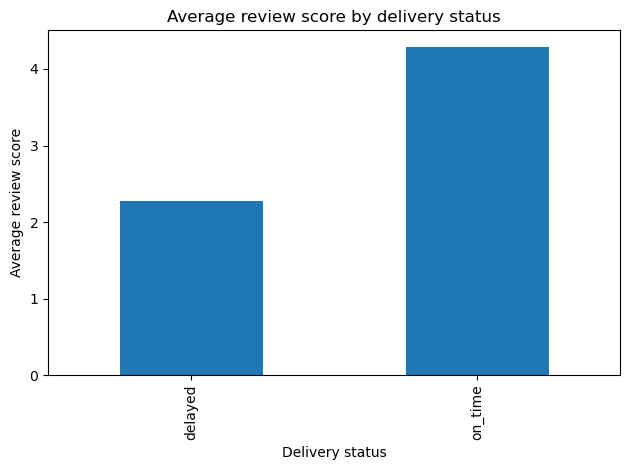

In [19]:
# [1.3-D] 시각화
#
# 힌트
# - kind = "bar"
# - x = "delivery_status"
# - y = "avg_review_score"

ax = delivery_review_df.plot(
    kind="bar",
    x="delivery_status",
    y="avg_review_score",
    legend=False
)

ax.set_title("Average review score by delivery status")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Average review score")
plt.tight_layout()
plt.show()

### 1.3 해석
1. 정상 배송과 지연 배송의 평균 리뷰 점수는 어떻게 달랐는가?
- 정상 배송 주문 89,443건의 평균 리뷰 점수는 약 4.29점, 지연 배송 주문 6,381건은 약 2.27점으로, 지연 배송 집단이 약 2.02점 낮았다.
2. `delay_days`와 `is_delayed`를 둘 다 만든 이유는?
- delay_days는 실제 배송완료일에서 예상 배송일을 뺀 값으로, 얼마나 늦거나 일찍 도착했는지를 나타낸다. 반면 is_delayed는 지연 여부를 지연 1, 정상 0으로 구분하여 집단 비교를 쉽게 만든다. 두 변수를 함께 사용하면 정상·지연 집단의 차이뿐 아니라, 지연 기간이 길어질수록 리뷰 점수가 어떻게 달라지는지도 분석할 수 있다.
3. `order_mart`의 Grain은?
- 한 행이 주문 1건을 의미한다. 전체 행 수와 고유 order_id 수가 모두 99,441개이므로 주문별로 한 행씩 존재함을 확인할 수 있다.
4. 이 결과만으로 배송 지연이 리뷰 하락의 **원인**이라고 말할 수 있는가?
- 상품 품질, 판매자의 서비스, 고객 지역, 상품 카테고리 등도 배송 지연과 리뷰 하락에 영향을 줄 수 있기 때문에 그렇게 말하기에는 애매하다. 위의 결과는 단순히 지연 배송 집단에서 평균 리뷰 점수의 관련성만을 보여준다.
5. 추가로 확인하고 싶은 변수는?
- 주문 시기를 통해 성수기의 영향을 확인해볼 수 있을 것 같다.


---

## 1.4 재구매 고객은 몇 명인가? — 지표 정의 비교

### 정의 A
모든 주문을 구매로 간주

### 정의 B
`delivered` 주문만 성공한 구매로 간주

### 핵심
- 실제 고객 식별자: `customer_unique_id`
- 고객별 주문 순서: `ROW_NUMBER()`
- 직전 주문일: `LAG()`
- 재구매 고객: 주문 2회 이상


In [20]:
# [1.4-A] 정의 A/B 재구매율 비교
#
# 힌트
# - 두 CTE 모두 customer_unique_id 기준 GROUP BY
# - 정의 B에만 delivered 필터
# - repeat customer는 order_count >= 2

repeat_customer_sql = """
WITH all_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),

delivered_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    'all_orders' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM all_orders

UNION ALL

SELECT
    'delivered_only' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM delivered_orders;
"""

repeat_customer_df = run_sql(repeat_customer_sql)
repeat_customer_df


,definition,customer_count,repeat_customer_count,repeat_customer_rate_pct
0,all_orders,96096,2997.0,3.12
1,delivered_only,93358,2801.0,3.00


In [21]:
# [1.4-B] ROW_NUMBER + LAG
#
# 두 Window Function 모두:
# PARTITION BY customer_unique_id
# ORDER BY order_purchase_timestamp, order_id
#
# order_id를 두 번째 정렬 기준으로 넣는 이유:
# 같은 timestamp가 있어도 순서를 안정적으로 결정하기 위해서입니다.

customer_history_sql = """
WITH ordered_customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS order_number,

        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS previous_order_timestamp

    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
)

SELECT
    *,
    DATEDIFF(
        order_purchase_timestamp,
        previous_order_timestamp
    ) AS days_since_previous_order

FROM ordered_customer_orders
WHERE previous_order_timestamp IS NOT NULL;
"""

customer_history_df = run_sql(customer_history_sql)
customer_history_df.head()


,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_number,previous_order_timestamp,days_since_previous_order
0,00172711b30d52eea8b313a7f2cced02,c306eca42d32507b970739b5b6a5a33a,canceled,2018-08-13 09:14:07,2,2018-07-28 00:23:49,16
1,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,delivered,2018-01-14 07:36:54,2,2017-07-27 14:13:03,171
2,004b45ec5c64187465168251cd1c9c2f,9392c5e72885ad5aba87e6223ca9838d,delivered,2018-05-26 19:42:48,2,2017-09-01 12:11:23,267
3,0058f300f57d7b93c477a131a59b36c3,81a93b2fa39e104b865b2bc471c16008,delivered,2018-03-22 18:09:41,2,2018-02-19 17:11:34,31
4,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,delivered,2018-06-03 10:12:57,2,2018-05-23 20:14:21,11


In [22]:
# [1.4-C] 같은 날 발생한 후속 주문 수
#
# 힌트:
# days_since_previous_order == 0 인 행 개수

same_day_repeat_count = (
    customer_history_df["days_since_previous_order"] == 0
).sum()

print("same-day repeat rows:", same_day_repeat_count)


same-day repeat rows: 961


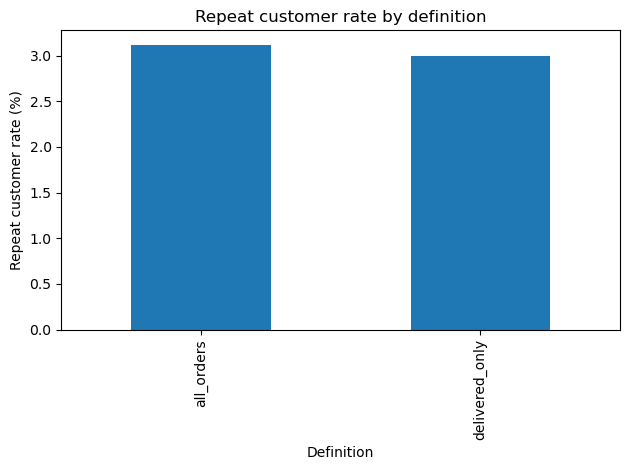

In [23]:
# [1.4-D] 정의 A/B 재구매율 시각화
#
# 힌트:
# kind = "bar"
# x = "definition"
# y = "repeat_customer_rate_pct"

ax = repeat_customer_df.plot(
    kind="bar",
    x="definition",
    y="repeat_customer_rate_pct",
    legend=False
)

ax.set_title("Repeat customer rate by definition")
ax.set_xlabel("Definition")
ax.set_ylabel("Repeat customer rate (%)")
plt.tight_layout()
plt.show()


### 1.4 해석
1. 왜 `customer_id`가 아니라 `customer_unique_id`를 사용해야 하는가?
- customer_id는 주문에 연결된 고객 식별자로, 같은 고객이 여러 번 주문하더라도 서로 다른 값으로 기록될 수 있기 때문에 이를 기준으로 집계하면 동일 고객의 여러 주문을 연결하지 못해 재구매를 제대로 파악하기 어려워진다. 반면 customer_unique_id는 여러 주문에서 동일 고객을 식별할 수 있는 값이므로, 고객별 주문 횟수와 재구매 여부를 계산할 때 사용할 수 있다.
2. 정의 A/B의 재구매율이 다른 이유는?
- 정의 A는 주문 상태와 관계없이 모든 주문을 구매로 간주하는 반면 B는 배송 완료된 주문만 구매로 간주한다.
3. 본인은 어떤 정의가 더 적절하다고 보는가?
- 취소되거나 배송이 완료되지 않은 주문까지 구매로 인정하면 실제 구매 성과를 왜곡할 수 있기에 B가 적절하다.
4. 같은 날 발생한 후속 주문을 재구매로 볼 것인가?
- 추가 구매와 같은 경우도 있기 때문에 재구매로 단정지을 수 없다고 생각한다.
5. **SQL보다 지표 정의가 먼저**라는 말의 의미는?
- SQL문을 작성하기 전에 누구를 고객으로 볼지, 어떤 주문을 구매로 인정할지, 같은 날 주문을 포함할지 등을 먼저 정해야 한다는 의미이다. 분석 목적에 달라 결과와 해석이 달라지기 때문이다.


---

## 1.5 월별 매출 변화 + 카테고리 원인 분해

배송 완료 주문 기준, **2017-01 ~ 2018-08** 분석

### 계산
- 월별 매출
- 전월 매출
- 전월 대비 증감액
- MoM 증감률
- 가장 큰 감소 구간
- 해당 구간의 카테고리별 변화


In [24]:
# [1.5-A] 월별 매출 + LAG
#
# 힌트
# - month = DATE_FORMAT(order_purchase_timestamp, '%Y-%m')
# - revenue = SUM(oi.price)
# - order_count = COUNT(DISTINCT o.order_id)
# - customer_count = COUNT(DISTINCT c.customer_unique_id)
# - delivered만 사용
# - 기간: '2017-01-01' 이상, '2018-09-01' 미만
# - previous_revenue = LAG(revenue) OVER (ORDER BY month)

monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue,
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT c.customer_unique_id) AS customer_count

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
      AND o.order_purchase_timestamp <  '2018-09-01'

    GROUP BY DATE_FORMAT(
        o.order_purchase_timestamp,
        '%Y-%m'
    )
),

monthly_with_previous AS (
    SELECT
        month,
        revenue,
        order_count,
        customer_count,
        LAG(revenue) OVER (
            ORDER BY month
        ) AS previous_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    order_count,
    customer_count,
    ROUND(previous_revenue, 2) AS previous_revenue,

    ROUND(
        revenue - previous_revenue,
        2
    ) AS mom_change,

    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS growth_rate_pct

FROM monthly_with_previous
ORDER BY month;
"""

monthly_sales_df = run_sql(monthly_sales_sql)
monthly_sales_df


,month,revenue,order_count,customer_count,previous_revenue,mom_change,growth_rate_pct
0,2017-01,111798.36,750,718,NaN,NaN,NaN
1,2017-02,234223.40,1653,1630,111798.36,122425.04,109.51
2,2017-03,359198.85,2546,2508,234223.40,124975.45,53.36
3,2017-04,340669.68,2303,2274,359198.85,-18529.17,-5.16
4,2017-05,489338.25,3546,3479,340669.68,148668.57,43.64
5,2017-06,421923.37,3135,3076,489338.25,-67414.88,-13.78
6,2017-07,481604.52,3872,3802,421923.37,59681.15,14.15
7,2017-08,554699.70,4193,4114,481604.52,73095.18,15.18
8,2017-09,607399.67,4150,4083,554699.70,52699.97,9.50
9,2017-10,648247.65,4478,4417,607399.67,40847.98,6.73


In [25]:
# [1.5-B] 가장 큰 감소 월
#
# 힌트:
# growth_rate_pct가 가장 작은 행을 찾습니다.

worst_idx = monthly_sales_df["growth_rate_pct"].idxmin()
worst_month = monthly_sales_df.loc[worst_idx]

print(worst_month)


month                 2017-12
revenue             726033.19
order_count              5513
customer_count           5450
previous_revenue    987765.37
mom_change         -261732.18
growth_rate_pct         -26.5
Name: 11, dtype: object


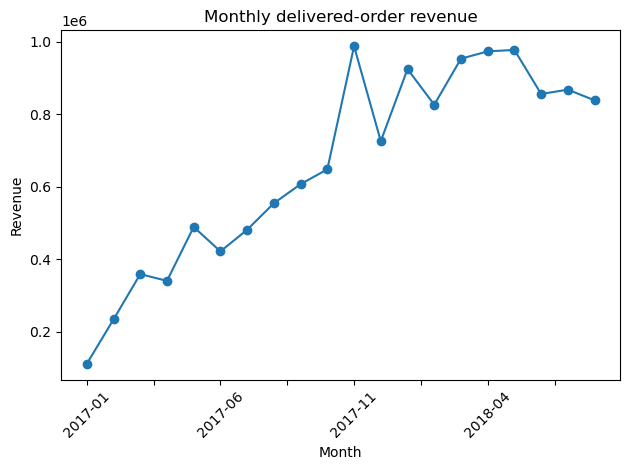

In [26]:
# [1.5-C] 월별 매출 추이
#
# 힌트:
# kind = "line"
# x = "month"
# y = "revenue"

ax = monthly_sales_df.plot(
    kind="line",
    x="month",
    y="revenue",
    marker="o",
    legend=False
)

ax.set_title("Monthly delivered-order revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
# [1.5-D] 2017-11 vs 2017-12 카테고리별 변화
#
# 힌트
# - 카테고리: 번역명이 있으면 영어명, 없으면 원래 카테고리명
# - revenue = SUM(oi.price)
# - delivered만 사용
# - 기간: '2017-11-01' 이상, '2018-01-01' 미만
# - 11월/12월 매출은 conditional aggregation으로 같은 행에 배치
#
# 주의:
# 카테고리별 단순 LAG는 어떤 달의 데이터가 없으면
# '직전 월'이 아닌 '직전에 존재하는 달'을 비교할 수 있습니다.

category_change_sql = """
WITH category_monthly_sales AS (
    SELECT
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ) AS category,

        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_products_dataset AS pr
      ON oi.product_id = pr.product_id
    LEFT JOIN product_category_name_translation AS tr
      ON pr.product_category_name = tr.product_category_name

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp <  '2018-01-01'

    GROUP BY
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ),
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        )
),

category_compare AS (
    SELECT
        category,

        SUM(
            CASE
                WHEN month = '2017-11' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_11,

        SUM(
            CASE
                WHEN month = '2017-12' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_12

    FROM category_monthly_sales
    GROUP BY category
)

SELECT
    category,
    ROUND(revenue_2017_11, 2) AS revenue_2017_11,
    ROUND(revenue_2017_12, 2) AS revenue_2017_12,

    ROUND(
        revenue_2017_12 - revenue_2017_11,
        2
    ) AS change_amount

FROM category_compare
ORDER BY change_amount ASC
LIMIT 10;
"""

category_change_df = run_sql(category_change_sql)
category_change_df


,category,revenue_2017_11,revenue_2017_12,change_amount
0,bed_bath_table,87957.63,50081.16,-37876.47
1,computers_accessories,69676.32,37428.67,-32247.65
2,furniture_decor,62091.27,31073.09,-31018.18
3,watches_gifts,95292.34,69556.92,-25735.42
4,cool_stuff,55696.66,37515.57,-18181.09
5,health_beauty,78274.40,60688.75,-17585.65
6,garden_tools,44275.18,26795.69,-17479.49
7,telephony,26117.63,12780.44,-13337.19
8,office_furniture,17919.20,6684.37,-11234.83
9,agro_industry_and_commerce,13932.49,5291.70,-8640.79


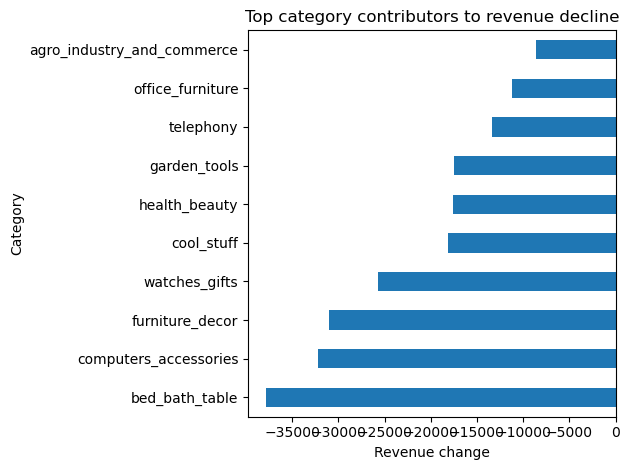

In [28]:
# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values("change_amount")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


### 1.5 해석
1. 가장 큰 매출 감소 시점은?
- 2017/11에서 2017/12로 넘어갈때 -26.5%로 감소율이 가장 컸다.
2. 감소 폭은?
- 987,765.37에서 726,033.19로 261,732.18만큼 감소했다.
3. 감소에 크게 기여한 카테고리는?
- 감소 금액이 큰 상위 5개 카테고리는 bed_bath_table, computers_accessories, furniture_decor, watches_gifts, cool_stuff이다.
4. 이 결과만으로 실제 **원인**을 확정할 수 있는가?
- 카테고리별 분석은 매출 감소가 어느 영역에서 발생했는지를 보여주지만, 왜 감소했는지까지 설명하지는 못한다.
5. 추가로 필요한 데이터는?
- 주문 취소·반품 내역, 여러 해의 같은 달 매출을 데이터를 구한다면 취소 문제와 특정 해의 영향을 찾아내는 데 도움이 될 것이다.


# 2. 심화 과제 — 아래 중 1개 선택


### A. 배송
배송 지연이 많은 판매자 또는 카테고리 분석

### B. 고객
1회 구매 고객 vs 2회 이상 구매 고객 평균 주문금액 비교

### C. 매출
매출 변화가 큰 시점을 지역 또는 카테고리 관점에서 분해

### D. 자유 분석
상급자에게 보고할 가치가 있는 질문을 직접 정의


In [37]:
# [B-1] 검증 쿼리: 집계 전 주문 수 확인

validation_sql = """
SELECT COUNT(*) AS order_count
FROM olist_orders_dataset
WHERE order_status = 'delivered';
"""

validation_df = run_sql(validation_sql)
before_order_count = int(validation_df.loc[0, "order_count"])
print("집계 전 주문 수:", before_order_count)

집계 전 주문 수: 96478


In [38]:
# [B-2] 심화 과제 공통 Skeleton

deep_dive_sql = """
WITH base AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count,
        SUM(oi.price) AS total_amount
    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

summary AS (
    SELECT
        CASE WHEN order_count = 1 THEN 'one_time' ELSE 'repeat' END AS customer_group,
        COUNT(*) AS customer_count,
        SUM(order_count) AS order_count,
        ROUND(SUM(total_amount), 2) AS item_amount,
        ROUND(
            SUM(total_amount) / NULLIF(SUM(order_count), 0), 2
        ) AS avg_order_amount
    FROM base
    GROUP BY CASE WHEN order_count = 1 THEN 'one_time' ELSE 'repeat' END
)

SELECT *
FROM summary
ORDER BY customer_group;
"""

deep_dive_df = run_sql(deep_dive_sql)
after_order_count = int(deep_dive_df["order_count"].sum())
print("집계 후 주문 수:", after_order_count)
assert before_order_count == after_order_count, "집계 전/후 주문 수가 다릅니다."
print("검증 통과: 집계 전/후 주문 수 일치")
display(deep_dive_df.head())

집계 후 주문 수: 96478
검증 통과: 집계 전/후 주문 수 일치


,customer_group,customer_count,order_count,item_amount,avg_order_amount
0,one_time,90557,90557.0,12493089.36,137.96
1,repeat,2801,5921.0,728408.75,123.02


### 심화 과제 작성

- 분석 질문:
  B: 배송 완료 주문을 기준으로, 1회 구매 고객과 2회 이상 구매 고객의 평균 주문금액에 차이가 있는가?

- 분석 Grain:  
  `base`는 **고객 1명당 1행**, `summary`는 **구매 집단당 1행**이다. 고객은 `customer_unique_id`로 구분하며, 최종 결과는 1회 구매 집단과 2회 이상 구매 집단으로 구성된다.

- 사용 테이블:  
  `olist_orders_dataset`, `olist_order_items_dataset`, `olist_customers_dataset`

- JOIN Key:
  주문과 상품 테이블은 `order_id`로 연결하고, 주문과 고객 테이블은 `customer_id`로 연결한다.

- 지표 / 파생변수:  
  고객별 고유 주문 수가 1건이면 `one_time`, 2건 이상이면 `repeat`로 분류한다. 각 집단의 **고객 수, 주문 수, 상품금액 합계, 평균 주문금액**을 계산한다. 평균 주문금액은 **집단의 상품금액 합계 ÷ 집단의 주문 수**로 정의하며, 배송비는 제외한다.

- 필터 기준:
  `order_status = 'delivered'`인 주문만 사용한다. 별도 기간 제한 없이 데이터에 포함된 전체 관측 기간을 분석하며, 같은 날 발생했더라도 서로 다른 주문이면 구매 횟수에 포함한다.

- 검증 방법:
  집계 전 배송 완료 주문 수는 96,478건이다. 집계 후 1회 구매 집단의 90,557건과 2회 이상 구매 집단의 5,921건을 합하면 96,478건으로 일치하여 검증을 통과했다.

- 핵심 숫자 2~3개:
  1회 구매 고객의 평균 주문금액: 137.96, 2회 이상 구매 고객의 평균 주문금액: 123.02, 평균 주문금액 차이: −14.94 (2회 이상 구매 집단이 더 낮음을 확인할 수 있음)

- 해석:
  1회 구매 고객 90,557명의 평균 주문금액은 137.96, 2회 이상 구매 고객 2,801명의 평균 주문금액은 123.02로 나타났다. 재구매 집단의 평균 주문금액이 약 14.94 낮아, 구매 횟수가 많은 고객이 주문 한 건에 더 큰 금액을 지출하는 것은 아님을 확인할 수 있다.

- 한계 / 추가 분석:
  고객별 관측 기간이 달라 최근 유입된 고객은 재구매할 기회가 적었을 수 있다. 또한 같은 날의 추가 주문도 재구매로 포함했고, 상품 카테고리·가격대·할인 여부를 통제하지 않았다. 추가로 첫 구매 후 동일한 기간을 관찰하거나, 같은 날 주문을 제외한 기준 및 카테고리별 평균 주문금액을 비교해볼 수 있을 것 같다.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: Grain, COUNT(DISTINCT)의 적용 범위, 비율의 분모 설정이 조금 어려웠던 것 같다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: 재구매 고객의 평균 주문금액이 더 낮게 나타나, 구매 횟수가 많다고 주문당 금액도 큰 것은 아님을 알았다. 또한 평균 주문금액과 고객당 누적 구매금액을 구분해야 한다는 점도 배웠다.

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
B 검증 쿼리 알려줘


**B-1에 아래 코드를 넣어 집계 전 주문 수를 확인하면 됩니다.**

```python
validation_sql = """
SELECT COUNT(*) AS order_count
FROM olist_orders_dataset
WHERE order_status = 'delivered';
"""

validation_df = run_sql(validation_sql)
before_order_count = int(validation_df.loc[0, "order_count"])

print("집계 전 주문 수:", before_order_count)
```

이후 **B-2에서 `deep_dive_df`를 만든 다음**, 아래 코드로 비교하세요.

```python
after_order_count = int(deep_dive_df["order_count"].sum())

print("집계 후 주문 수:", after_order_count)

assert before_order_count == after_order_count, "집계 전/후 주문 수가 다릅니다."

print("✅ 검증 통과: 집계 전/후 주문 수가 일치합니다.")
```

배송 완료 주문 수와 **1회·2회 이상 구매 집단의 주문 수 합계**가 같은지 확인하는 검증입니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? (여기에 답)